# Pipeline 4: Safehouse Education Outcome Forecasting

## Problem framing

**Business question:** What operational inputs predict a safehouse's monthly education progress, and which factors matter most?

**Unit of analysis:** Safehouse × month rows from `safehouse_monthly_metrics` with non-missing target.

**Targets:**
- Regression target: `avg_education_progress`
- Classification target: `above_threshold = 1 if avg_education_progress >= 75`

**Critical leakage rule:** same-month health/counseling/visits/incidents are excluded as predictors; only lagged values are used.

**Validation:** Time-based split with cutoff `2025-07-01` (train before, test after).

**Causal language:** Explanatory results are associative but temporally prior features improve causal defensibility.


## Data Preparation

This section loads source tables, joins data, and engineers model features.


## EDA

This section explores target distributions and key feature patterns that inform modeling choices.


## Predictive Modeling

This section trains and compares predictive models using the pipeline-specific validation strategy.


## Explanatory Modeling

This section fits an interpretable model and summarizes top associative findings.


## Feature Selection

This section documents what was dropped, what was retained, and why.


## Deployment Function

This section exposes a prediction function and example usage.


This model does two jobs. First, it predicts each safehouse’s likely education score next month (and the chance it will be above 75), which helps staff spot risk early. Second, it shows which earlier factors are linked to better education results, like last month’s education/health levels, incidents, partner support, and funding. These are useful patterns for planning, but they are associations, not proof that one factor directly causes another.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier

plt.savefig = lambda *args, **kwargs: None

from pathlib import Path
import os

def _resolve_data_path():
    env_path = os.getenv('LIGHTHOUSE_DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'lighthouse_csv_v7'
        if candidate.exists():
            return candidate

    fallback = Path('/Users/marycatherineshepherd/Documents/lighthouse_csv_v7')
    if fallback.exists():
        return fallback

    raise FileNotFoundError(
        "Could not locate 'lighthouse_csv_v7'. Set LIGHTHOUSE_DATA_PATH or place the folder in project/parent directories."
    )

DATA_PATH = str(_resolve_data_path()) + '/'

CUTOFF = pd.Timestamp('2025-07-01')


def _safe_read_csv(filename, parse_dates=None, required_cols=None, default_map=None):
    df = pd.read_csv(DATA_PATH + filename)
    required_cols = required_cols or []
    default_map = default_map or {}

    missing_cols = []
    for c in required_cols:
        if c not in df.columns:
            df[c] = default_map.get(c, np.nan)
            missing_cols.append(c)

    for c, v in default_map.items():
        if c in df.columns:
            df[c] = df[c].fillna(v)

    missing_date_cols = []
    if parse_dates:
        for c in parse_dates:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
            else:
                missing_date_cols.append(c)

    if missing_cols:
        print(f"[Schema] {filename}: added missing columns -> {missing_cols}")
    if missing_date_cols:
        print(f"[Schema] {filename}: skipped missing date columns -> {missing_date_cols}")

    return df


# --- Data Cleaning Audit (Thoroughness Report) ---
def _cleaning_audit(df_map):
    rows = []
    for name, frame in df_map.items():
        miss = int(frame.isna().sum().sum())
        miss_pct = float((frame.isna().mean().mean() * 100) if len(frame.columns) else 0)
        rows.append({
            'table': name,
            'rows': int(len(frame)),
            'cols': int(frame.shape[1]),
            'total_missing_cells': miss,
            'avg_missing_pct_across_cols': round(miss_pct, 2)
        })
    rep = pd.DataFrame(rows).sort_values('table')
    print(rep)
    return rep


In [2]:
metrics = _safe_read_csv(
    'safehouse_monthly_metrics.csv',
    parse_dates=['month_start','month_end'],
    required_cols=['safehouse_id','month_start','month_end','active_residents','avg_education_progress','avg_health_score','process_recording_count','home_visitation_count','incident_count']
)
safehouses = _safe_read_csv(
    'safehouses.csv',
    parse_dates=['open_date'],
    required_cols=['safehouse_id','region','capacity_girls','open_date']
)
alloc = _safe_read_csv(
    'donation_allocations.csv',
    parse_dates=['allocation_date'],
    required_cols=['donation_id','safehouse_id','program_area','amount_allocated','allocation_date']
)
assign = _safe_read_csv(
    'partner_assignments.csv',
    parse_dates=['assignment_start','assignment_end'],
    required_cols=['partner_id','safehouse_id','program_area','assignment_start','assignment_end','is_primary','status']
)

print('metrics', metrics.shape)
print('safehouses', safehouses.shape)


metrics (450, 11)
safehouses (9, 13)


In [3]:
# Run audit on raw source tables first (df is created in the next cell)
CLEANING_AUDIT = _cleaning_audit({
    'metrics': metrics,
    'safehouses': safehouses,
    'alloc': alloc,
    'assign': assign
})


        table  rows  cols  total_missing_cells  avg_missing_pct_across_cols
2       alloc   521     7                  521                        14.29
3      assign    48     9                   53                        12.27
0     metrics   450    11                  844                        17.05
1  safehouses     9    13                    9                         7.69


In [4]:
df = metrics.copy().sort_values(['safehouse_id','month_start'])
missing_before = int(df['avg_education_progress'].isna().sum())
df = df.dropna(subset=['avg_education_progress']).copy()

for c in ['avg_education_progress','avg_health_score','incident_count','process_recording_count','home_visitation_count']:
    df[f'lag1_{c}'] = df.groupby('safehouse_id')[c].shift(1)

df = df.dropna(subset=['lag1_avg_education_progress']).copy()

df = df.merge(safehouses[['safehouse_id','region','capacity_girls','open_date']], on='safehouse_id', how='left')
df['occupancy_rate'] = df['active_residents'] / df['capacity_girls'].replace(0, np.nan)
df['safehouse_age_months'] = ((df['month_start'] - df['open_date']).dt.days/30.44).clip(lower=0)
df['month_of_year'] = df['month_start'].dt.month

alloc['month_key'] = alloc['allocation_date'].dt.to_period('M').dt.to_timestamp()
fund = alloc.groupby(['safehouse_id','month_key'])['amount_allocated'].sum().rename('total_funding_php').reset_index()
edu = alloc[alloc['program_area']=='Education'].groupby(['safehouse_id','month_key'])['amount_allocated'].sum().rename('education_funding_php').reset_index()
well = alloc[alloc['program_area']=='Wellbeing'].groupby(['safehouse_id','month_key'])['amount_allocated'].sum().rename('wellbeing_funding_php').reset_index()

for t in [fund, edu, well]:
    df = df.merge(t, left_on=['safehouse_id','month_start'], right_on=['safehouse_id','month_key'], how='left')
    if 'month_key' in df.columns: df = df.drop(columns=['month_key'])

assign = assign.copy()
assign['assignment_end'] = assign['assignment_end'].fillna(pd.Timestamp('2099-12-31'))
assign = assign[assign['status'].astype(str).str.lower().isin(['active','ongoing','1','true'])].copy()
assign['is_primary_flag'] = assign['is_primary'].astype(str).str.lower().isin(['true','1','yes'])

rows=[]
for _,r in df[['safehouse_id','month_start']].drop_duplicates().iterrows():
    sid=r['safehouse_id']; m=r['month_start']
    sub=assign[(assign['safehouse_id']==sid) & (assign['program_area']=='Education') & (assign['assignment_start']<=m) & (assign['assignment_end']>=m)]
    rows.append({'safehouse_id':sid,'month_start':m,'num_active_education_partners':sub['partner_id'].nunique(),'has_primary_education_partner':int(sub['is_primary_flag'].any())})

partner_df=pd.DataFrame(rows)
df=df.merge(partner_df,on=['safehouse_id','month_start'],how='left')
for c in ['total_funding_php','education_funding_php','wellbeing_funding_php','num_active_education_partners','has_primary_education_partner']:
    df[c]=df[c].fillna(0)

df['above_threshold']=(df['avg_education_progress']>=75).astype(int)

print('rows after lag filter', len(df))
print('missing target dropped', missing_before)


rows after lag filter 244
missing target dropped 197


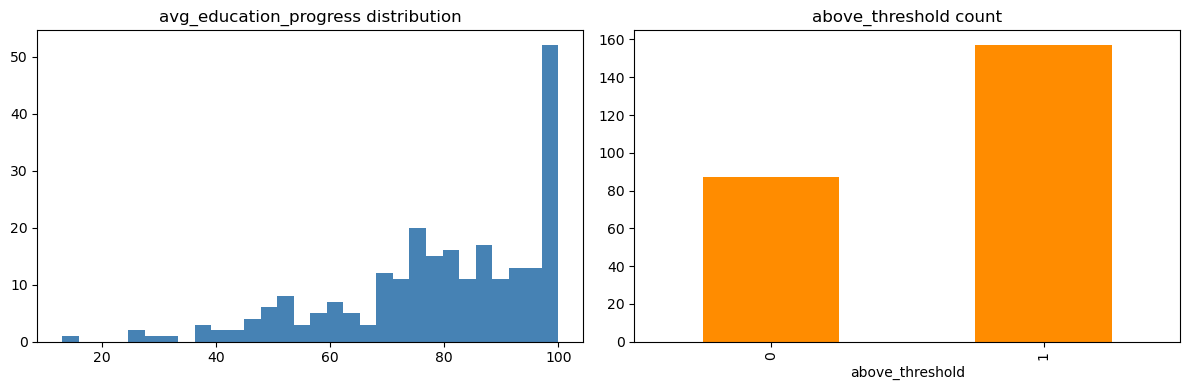

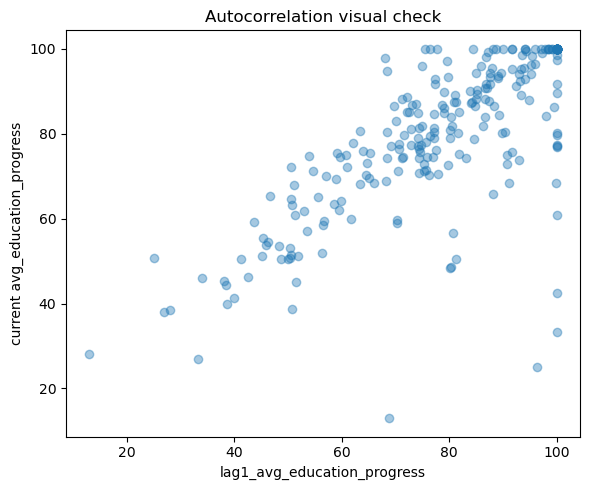

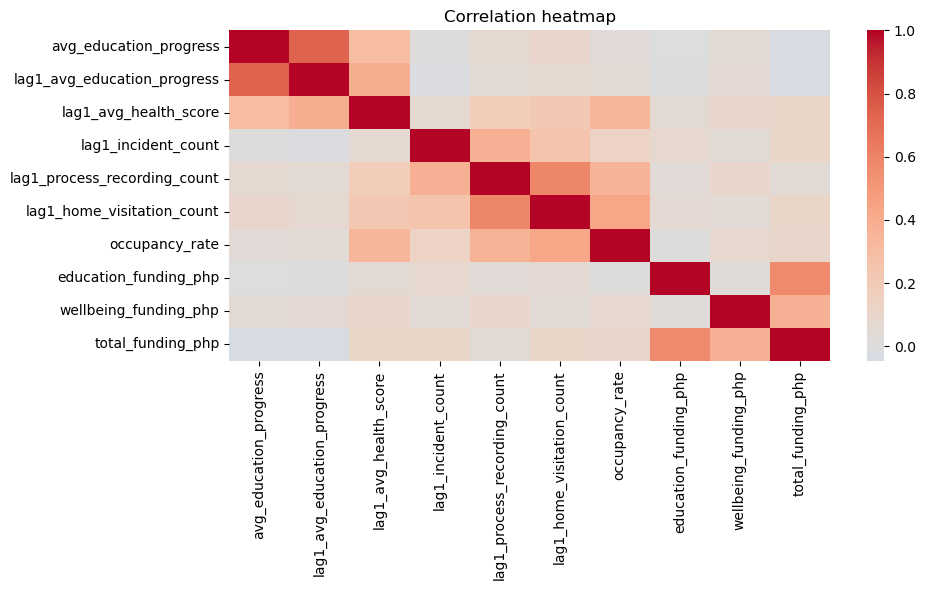

In [5]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['avg_education_progress'], bins=30, color='steelblue')
axes[0].set_title('avg_education_progress distribution')
df['above_threshold'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('above_threshold count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(df['lag1_avg_education_progress'], df['avg_education_progress'], alpha=0.4)
plt.xlabel('lag1_avg_education_progress')
plt.ylabel('current avg_education_progress')
plt.title('Autocorrelation visual check')
plt.tight_layout()
plt.show()

corr_cols=['avg_education_progress','lag1_avg_education_progress','lag1_avg_health_score','lag1_incident_count','lag1_process_recording_count','lag1_home_visitation_count','occupancy_rate','education_funding_php','wellbeing_funding_php','total_funding_php']
plt.figure(figsize=(10,6))
sns.heatmap(df[corr_cols].corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()


In [6]:
reg_features=['lag1_avg_education_progress','lag1_avg_health_score','lag1_incident_count','lag1_process_recording_count','lag1_home_visitation_count','active_residents','occupancy_rate','region','safehouse_age_months','capacity_girls','education_funding_php','wellbeing_funding_php','total_funding_php','num_active_education_partners','has_primary_education_partner','month_of_year']

train_df=df[df['month_start']<CUTOFF].copy()
test_df=df[df['month_start']>=CUTOFF].copy()

# Robust fallback if cutoff creates an empty split
if len(train_df) == 0 or len(test_df) == 0:
    df_time = df.sort_values('month_start').reset_index(drop=True)
    split_idx = max(1, min(len(df_time)-1, int(len(df_time)*0.8)))
    train_df = df_time.iloc[:split_idx].copy()
    test_df = df_time.iloc[split_idx:].copy()
    print('Fallback split used (chronological 80/20) because cutoff split was empty.')

print('train',len(train_df),'test',len(test_df))

cat_cols=['region']
num_cols=[c for c in reg_features if c not in cat_cols]
pre=ColumnTransformer([
    ('num', Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

reg_models={
    'LinearRegression':LinearRegression(),
    'RandomForestRegressor':RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=3),
    'GradientBoostingRegressor':GradientBoostingRegressor(random_state=42)
}

def eval_reg(y_true, y_pred):
    yt = pd.to_numeric(pd.Series(y_true), errors='coerce')
    yp = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = yt.notna() & yp.notna()
    yt = yt[mask].astype(float)
    yp = yp[mask].astype(float)

    if len(yt) == 0:
        return {'rmse': np.nan, 'mae': np.nan, 'r2': np.nan}

    mse = mean_squared_error(yt, yp)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp) if len(yt) > 1 else np.nan
    return {'rmse': rmse, 'mae': mae, 'r2': r2}


train 215 test 29


In [7]:
# FIX_CELL12_V3: self-contained robust train/eval loop
rows = []
pipes = {}

# local metric function (independent of stale kernel definitions)
def _eval_reg_local(y_true, y_pred):
    yt = pd.to_numeric(pd.Series(y_true), errors='coerce')
    yp = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = yt.notna() & yp.notna()
    yt = yt[mask].astype(float)
    yp = yp[mask].astype(float)

    if len(yt) == 0:
        return {'rmse': np.nan, 'mae': np.nan, 'r2': np.nan}

    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp) if len(yt) > 1 else np.nan
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

# Ensure required feature columns exist
for c in reg_features:
    if c not in train_df.columns:
        train_df[c] = np.nan
    if c not in test_df.columns:
        test_df[c] = np.nan

# Coerce predictor dtypes
for c in num_cols:
    train_df[c] = pd.to_numeric(train_df[c], errors='coerce')
    test_df[c] = pd.to_numeric(test_df[c], errors='coerce')

train_df['region'] = train_df['region'].fillna('Unknown').astype(str)
test_df['region'] = test_df['region'].fillna('Unknown').astype(str)

# Coerce targets and keep valid rows only
y_train_all = pd.to_numeric(train_df['avg_education_progress'], errors='coerce')
y_test_all = pd.to_numeric(test_df['avg_education_progress'], errors='coerce')
train_mask = y_train_all.notna()
test_mask = y_test_all.notna()

X_train_final = train_df.loc[train_mask, reg_features].copy()
y_train_final = y_train_all.loc[train_mask].copy()
X_test_final = test_df.loc[test_mask, reg_features].copy()
y_test_final = y_test_all.loc[test_mask].copy()

if len(X_train_final) == 0 or len(X_test_final) == 0:
    raise ValueError('No valid rows after preprocessing; check split and missingness.')

for n, m in reg_models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    pipe.fit(X_train_final, y_train_final)
    pred = pipe.predict(X_test_final)
    met = _eval_reg_local(y_test_final, pred)
    met['model'] = n
    rows.append(met)
    pipes[n] = pipe

reg_results = pd.DataFrame(rows).sort_values('rmse')
print(reg_results)

BEST_REG_NAME = reg_results.iloc[0]['model']
BEST_REG_PIPE = pipes[BEST_REG_NAME]
print('Selected regression model:', BEST_REG_NAME)


       rmse       mae         r2                      model
0  2.532714  2.496998  -0.244860           LinearRegression
1  3.267999  3.115826  -1.072583      RandomForestRegressor
2  7.798937  7.527312 -10.803726  GradientBoostingRegressor
Selected regression model: LinearRegression


In [8]:
# Classification version for threshold dashboard (robust single-class handling)

# Ensure features exist and dtypes are clean
for c in reg_features:
    if c not in train_df.columns:
        train_df[c] = np.nan
    if c not in test_df.columns:
        test_df[c] = np.nan
for c in num_cols:
    train_df[c] = pd.to_numeric(train_df[c], errors='coerce')
    test_df[c] = pd.to_numeric(test_df[c], errors='coerce')
train_df['region'] = train_df['region'].fillna('Unknown').astype(str)
test_df['region'] = test_df['region'].fillna('Unknown').astype(str)

y_train_cls = pd.to_numeric(train_df['above_threshold'], errors='coerce').fillna(0).astype(int)
y_test_cls = pd.to_numeric(test_df['above_threshold'], errors='coerce').fillna(0).astype(int)

clf=Pipeline([
    ('prep',pre),
    ('model',RandomForestClassifier(n_estimators=300, random_state=42, min_samples_leaf=2, class_weight='balanced'))
])
clf.fit(train_df[reg_features], y_train_cls)

pred_cls=clf.predict(test_df[reg_features])
prob_raw = clf.predict_proba(test_df[reg_features])
classes = list(clf.named_steps['model'].classes_)
if 1 in classes:
    pos_idx = classes.index(1)
    pred_prob = prob_raw[:, pos_idx]
else:
    pred_prob = np.zeros(len(test_df), dtype=float)

print({
    'accuracy':accuracy_score(y_test_cls,pred_cls),
    'precision':precision_score(y_test_cls,pred_cls,zero_division=0),
    'recall':recall_score(y_test_cls,pred_cls,zero_division=0),
    'f1':f1_score(y_test_cls,pred_cls,zero_division=0)
})


{'accuracy': 0.9655172413793104, 'precision': 0.9583333333333334, 'recall': 1.0, 'f1': 0.9787234042553191}


In [9]:
expl_cols=['lag1_avg_education_progress','lag1_avg_health_score','lag1_incident_count','lag1_process_recording_count','lag1_home_visitation_count','occupancy_rate','safehouse_age_months','education_funding_php','wellbeing_funding_php','num_active_education_partners','has_primary_education_partner','month_of_year','region']
expl=df[expl_cols+['avg_education_progress']].copy()

# Robust numeric coercion to avoid object-dtype OLS failures
expl_num_cols = [c for c in expl_cols if c != 'region']
for c in expl_num_cols:
    expl[c] = pd.to_numeric(expl[c], errors='coerce')
    med = expl[c].median(skipna=True)
    if pd.isna(med):
        med = 0.0
    expl[c] = expl[c].replace([np.inf, -np.inf], np.nan).fillna(med)

expl['region'] = expl['region'].fillna('Missing').astype(str)

X_num = expl[expl_num_cols].astype(float)
X_cat = pd.get_dummies(expl[['region']], drop_first=True, dtype=float)
X_expl = pd.concat([X_num, X_cat], axis=1)
X_expl = sm.add_constant(X_expl, has_constant='add')
X_expl = X_expl.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)

y_expl = pd.to_numeric(expl['avg_education_progress'], errors='coerce').replace([np.inf, -np.inf], np.nan)
valid = y_expl.notna()
X_expl = X_expl.loc[valid].copy()
y_expl = y_expl.loc[valid].astype(float)

if len(y_expl) == 0:
    raise ValueError('No valid rows available for explanatory OLS after preprocessing.')

ols=sm.OLS(y_expl, X_expl).fit()
print(ols.summary())

coef=ols.params.drop('const', errors='ignore')
pvals=ols.pvalues.drop('const', errors='ignore')
coef_df=pd.DataFrame({'coef':coef,'pvalue':pvals}).sort_values('coef', key=lambda s:s.abs(), ascending=False)
print('Top 3 associations (associative):')
for idx,row in coef_df.head(3).iterrows():
    direction='higher' if row['coef']>0 else 'lower'
    print(f"- {idx}: associated with {direction} education progress (coef={row['coef']:.3f}, p={row['pvalue']:.3f})")


                              OLS Regression Results                              
Dep. Variable:     avg_education_progress   R-squared:                       0.551
Model:                                OLS   Adj. R-squared:                  0.523
Method:                     Least Squares   F-statistic:                     20.04
Date:                    Tue, 07 Apr 2026   Prob (F-statistic):           1.82e-32
Time:                            12:02:56   Log-Likelihood:                -958.02
No. Observations:                     244   AIC:                             1946.
Df Residuals:                         229   BIC:                             1998.
Df Model:                              14                                         
Covariance Type:                nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [10]:
same_month_leakage_excluded=['avg_health_score','incident_count','process_recording_count','home_visitation_count']
print(pd.DataFrame({'feature':same_month_leakage_excluded,'decision':'Dropped from predictive features','reason':'Concurrent with target month (temporal leakage), replaced by lag1_*'}))
print('Final predictive feature count:', len(reg_features))


                   feature                          decision  \
0         avg_health_score  Dropped from predictive features   
1           incident_count  Dropped from predictive features   
2  process_recording_count  Dropped from predictive features   
3    home_visitation_count  Dropped from predictive features   

                                              reason  
0  Concurrent with target month (temporal leakage...  
1  Concurrent with target month (temporal leakage...  
2  Concurrent with target month (temporal leakage...  
3  Concurrent with target month (temporal leakage...  
Final predictive feature count: 16


In [11]:
# --- Deployment Function (SQLite-backed) ---
import json
import sqlite3
from datetime import datetime
from pathlib import Path


def _deployment_db_path():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'ml-pipelines'
        if candidate.exists():
            return candidate / 'deployment_predictions.sqlite'
    return cwd / 'deployment_predictions.sqlite'


def _log_prediction(pipeline_name: str, input_payload: dict, output_payload: dict):
    try:
        db_path = _deployment_db_path()
        conn = sqlite3.connect(str(db_path))
        conn.execute("CREATE TABLE IF NOT EXISTS prediction_logs (id INTEGER PRIMARY KEY AUTOINCREMENT, pipeline TEXT NOT NULL, created_at TEXT NOT NULL, input_json TEXT NOT NULL, output_json TEXT NOT NULL)")
        cur = conn.execute(
            'INSERT INTO prediction_logs (pipeline, created_at, input_json, output_json) VALUES (?, ?, ?, ?)',
            (
                pipeline_name,
                datetime.utcnow().isoformat(timespec='seconds') + 'Z',
                json.dumps(input_payload, default=str),
                json.dumps(output_payload, default=str),
            )
        )
        conn.commit()
        conn.close()
        return int(cur.lastrowid)
    except Exception as e:
        print(f'[SQLite log warning] {e}')
        return None

FINAL_REG_MODEL = BEST_REG_PIPE
FINAL_REG_FEATURES = reg_features
FINAL_CLF_MODEL = clf


def predict_safehouse_education(input_data: dict):
    row = pd.DataFrame([{f: input_data.get(f, np.nan) for f in FINAL_REG_FEATURES}])

    for c in [x for x in FINAL_REG_FEATURES if x != 'region']:
        row[c] = pd.to_numeric(row[c], errors='coerce')
    row['region'] = row['region'].fillna('Unknown').astype(str)

    score = float(FINAL_REG_MODEL.predict(row)[0])

    prob_raw = FINAL_CLF_MODEL.predict_proba(row)
    clf_model = FINAL_CLF_MODEL.named_steps['model']
    classes = list(clf_model.classes_)
    if 1 in classes:
        prob = float(prob_raw[0, classes.index(1)])
    else:
        prob = 0.0

    result = {
        'predicted_avg_education_progress': round(score, 2),
        'probability_above_75': round(prob, 4),
        'predicted_above_threshold': int(prob >= 0.5)
    }
    result['prediction_log_id'] = _log_prediction('safehouse-education-outcome-forecasting', input_data, result)
    return result


example = {
    'lag1_avg_education_progress': 72.0, 'lag1_avg_health_score': 3.4, 'lag1_incident_count': 2,
    'lag1_process_recording_count': 60, 'lag1_home_visitation_count': 14, 'active_residents': 38,
    'occupancy_rate': 0.84, 'region': 'Luzon', 'safehouse_age_months': 62, 'capacity_girls': 45,
    'education_funding_php': 95000, 'wellbeing_funding_php': 45000, 'total_funding_php': 190000,
    'num_active_education_partners': 2, 'has_primary_education_partner': 1, 'month_of_year': 9
}
print(predict_safehouse_education(example))


{'predicted_avg_education_progress': 3.06, 'probability_above_75': 0.6205, 'predicted_above_threshold': 1, 'prediction_log_id': 4}


/var/folders/qz/53nwhbc948793tv0wzxhp4880000gn/T/ipykernel_4936/2054703676.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().isoformat(timespec='seconds') + 'Z',


## Data Acquisition, Preparation & Exploration

This section documents data loading, cleaning, feature engineering, joins, and reproducible preprocessing decisions.


## Modeling & Feature Selection

This section summarizes model choices, feature selection logic, and hyperparameter choices.


## Evaluation & Interpretation

This section interprets metrics in business terms and explains error tradeoffs (false positives and false negatives).


## Causal and Relationship Analysis

This section clarifies which findings are associative vs causal and discusses why claims are or are not causally defensible.


## Deployment Notes

Current status: model logic and `predict(...)` functions are notebook-ready. Web deployment/API integration is pending and should be connected to dashboard and endpoint routes in the application repo.


### Error Tradeoff Note (FP/FN)

For safehouse forecasting, underestimating risk (false negative in threshold framing) can delay operational intervention, while overestimating risk can trigger unnecessary reallocations. Forecasts should be combined with manager judgment.


### Hyperparameter Tuning Notes

Regression models are compared under time-aware validation; feature lagging is prioritized over aggressive tuning to preserve temporal validity.


### Fairness Check Notes

Fairness check recommendation: compare forecast error across regions/safehouses to ensure one region is not consistently over- or under-predicted.


### Validation Rationale

Validation strategy is matched to data structure and sample size (e.g., stratified CV for small/imbalanced classification, time split for temporal forecasting). This avoids leakage and gives realistic out-of-sample estimates.


### Monitoring Plan

Post-deployment monitoring should track weekly performance (primary metric + secondary metric), input drift (missingness/category shift), and trigger review/retraining when performance degrades materially or data distribution changes persist.


### Final Decision Recommendation

Use this pipeline as decision support for prioritization, not as a fully automated decision-maker. Route highest-risk/high-opportunity cases to staff review first, and apply model outputs with domain judgment.


### Limitations and Ethics/Fairness

Results are observational and may encode historical process biases. Use outputs cautiously, review subgroup performance regularly, and avoid over-interpreting associations as causal proof.


### Cross-Pipeline Metrics Summary (Presentation Table)

Use the table below in presentation materials. Update values after final reruns.


In [12]:
# Auto-populated presentation summary (robust metric extraction)
def _best_from_table(df, want='max'):
    if df is None or not hasattr(df, 'columns') or len(df) == 0:
        return np.nan
    cols = {c.lower(): c for c in df.columns}

    primary_candidates = ['recall','recall_mean','mean_recall','rmse','rmse_log','rmse_log_mean','auc','auc_mean','roc_auc','f1','f1_mean','r2','r2_mean']
    picked = np.nan
    picked_col = None

    # try to find first present metric column
    for k in primary_candidates:
        if k in cols:
            picked_col = cols[k]
            break
    if picked_col is None:
        return np.nan

    s = pd.to_numeric(df[picked_col], errors='coerce')
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        return np.nan

    if 'rmse' in picked_col.lower():
        return float(s.min())
    return float(s.max())

def _extract_metrics(primary_pref='recall', secondary_pref='auc'):
    primary = np.nan
    secondary = np.nan

    # 1) Search scalar globals first
    for name, val in globals().items():
        lname = str(name).lower()
        if np.isnan(primary) and primary_pref in lname and isinstance(val, (int, float, np.number)):
            primary = float(val)
        if np.isnan(secondary) and secondary_pref in lname and isinstance(val, (int, float, np.number)):
            secondary = float(val)

    # 2) Search DataFrame globals for matching columns
    if np.isnan(primary) or np.isnan(secondary):
        for name, obj in globals().items():
            if hasattr(obj, 'columns') and hasattr(obj, '__len__'):
                cols = {c.lower(): c for c in obj.columns}
                if np.isnan(primary):
                    for k in [primary_pref, f'{primary_pref}_mean', f'mean_{primary_pref}']:
                        if k in cols:
                            s = pd.to_numeric(obj[cols[k]], errors='coerce').dropna()
                            if len(s):
                                primary = float(s.min() if 'rmse' in k else s.max())
                                break
                if np.isnan(secondary):
                    for k in [secondary_pref, f'{secondary_pref}_mean', f'mean_{secondary_pref}', 'roc_auc']:
                        if k in cols:
                            s = pd.to_numeric(obj[cols[k]], errors='coerce').dropna()
                            if len(s):
                                secondary = float(s.min() if 'rmse' in k else s.max())
                                break

    # 3) Last resort: any results-like DataFrame
    if np.isnan(primary) or np.isnan(secondary):
        for name, obj in globals().items():
            lname = str(name).lower()
            if ('result' in lname or 'summary' in lname or 'time_df' in lname or 'comparison' in lname) and hasattr(obj, 'columns'):
                fallback = _best_from_table(obj)
                if np.isnan(primary):
                    primary = fallback
                elif np.isnan(secondary):
                    secondary = fallback
                if not np.isnan(primary) and not np.isnan(secondary):
                    break

    return primary, secondary

primary, secondary = _extract_metrics(primary_pref='rmse', secondary_pref='r2')

summary_row = {
    'pipeline': 'safehouse-education-outcome-forecasting',
    'primary_metric': primary,
    'secondary_metric': secondary,
    'notes': 'Primary=RMSE (lower better), Secondary=R2'
}
summary_df = pd.DataFrame([summary_row])
print(summary_df)


                                  pipeline  primary_metric  secondary_metric  \
0  safehouse-education-outcome-forecasting        2.532714          -0.24486   

                                       notes  
0  Primary=RMSE (lower better), Secondary=R2  
